# Step 1 (V6): Baseline AI Classifier - Enriched Features (Opsi B)

## 🎯 Objective:
Meningkatkan akurasi predictive power dengan **memperkaya fitur (Feature Engineering)**. Kita menambahkan indikator teknikal yang lebih responsif dan data historis jangka pendek.

## ⚖️ Why V6 (Opsi B) covers the gap?
1.  **RSI (Relative Strength Index)**: Indikator momentum yang sangat populer untuk mendeteksi kondisi jenuh beli (*overbought*) atau jenuh jual (*oversold*). Ini memberikan sinyal 'balik arah' yang tidak ditangkap oleh Moving Average.
2.  **Lagged Returns (T-1, T-2)**: Memberikan model 'ingatan' tentang apa yang terjadi kemarin dan lusa. Pasar kripto sangat dipengaruhi oleh momentum jangka sangat pendek.
3.  **Standard Scaling**: Memastikan semua fitur (terutama RSI yang berskala 0-100) berada dalam rentang yang sama dengan Volatilitas (angka desimal).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')

print("✅ Libraries loaded. Starting V6 (Enriched Features)...")

✅ Libraries loaded. Starting V6 (Enriched Features)...


## 1. Feature Engineering: RSI & Lagged Returns

In [2]:
# Load data
data = pd.read_excel('dataset_2023_2025.xlsx', index_col=0, parse_dates=True)
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1)

def calculate_rsi(series, period=14):
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

features = pd.DataFrame(index=returns.index)

# Original Features
features['Vol_20'] = market_return.rolling(window=20).std()
features['Mom_20'] = market_return.rolling(window=20).mean()

# ENRICHED FEATURES (OPSI B)
features['RSI_14'] = calculate_rsi(market_return, 14)
features['Return_Lag1'] = market_return.shift(1)
features['Return_Lag2'] = market_return.shift(2)
features['Vol_60'] = market_return.rolling(window=60).std()

# Target (5-Day Trend from V2)
window_target = 5
features['Target'] = (market_return.rolling(window=window_target).mean().shift(-window_target) > 0).astype(int)

features = features.dropna()
print(f"📊 Total Features: {len(features.columns)-1}")
print(features.head())

📊 Total Features: 6
              Vol_20    Mom_20     RSI_14  Return_Lag1  Return_Lag2    Vol_60  \
Date                                                                            
2023-06-29  0.030757  0.004926  56.360172    -0.057443     0.008844  0.026120   
2023-06-30  0.028099  0.011781  56.429259     0.060867    -0.057443  0.027310   
2023-07-01  0.027879  0.012263  49.922553     0.066064     0.060867  0.027307   
2023-07-02  0.027819  0.012475  51.491980     0.004674     0.066064  0.027305   
2023-07-03  0.027807  0.012519  50.118786     0.007099     0.004674  0.027057   

            Target  
Date                
2023-06-29       1  
2023-06-30       0  
2023-07-01       0  
2023-07-02       0  
2023-07-03       0  


## 2. Train/Test Split & Standardization

In [3]:
X = features.drop('Target', axis=1)
y = features['Target']

X_train, y_train = X[X.index.year <= 2024], y[y.index.year <= 2024]
X_test, y_test = X[X.index.year == 2025], y[y.index.year == 2025]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Data points: Training={len(X_train)}, Testing={len(X_test)}")

Data points: Training=552, Testing=365


## 3. Modeling & Evaluation


--- Performance Table (V6: Enriched Features) ---
 Dataset            Model  Accuracy
Training Random Forest V6  0.764493
 Testing Random Forest V6  0.517808
Training        LogReg V6  0.617754
 Testing        LogReg V6  0.594521


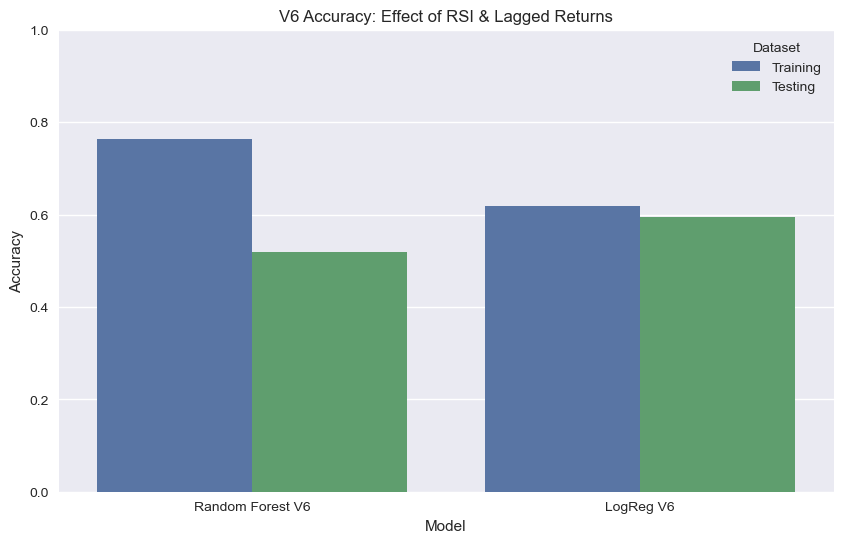

In [4]:
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, min_samples_leaf=15, random_state=42)
rf_model.fit(X_train_scaled, y_train)

lr_model = LogisticRegression(C=0.1)
lr_model.fit(X_train_scaled, y_train)

results = {
    'Dataset': ['Training', 'Testing', 'Training', 'Testing'],
    'Model': ['Random Forest V6', 'Random Forest V6', 'LogReg V6', 'LogReg V6'],
    'Accuracy': [
        accuracy_score(y_train, rf_model.predict(X_train_scaled)),
        accuracy_score(y_test, rf_model.predict(X_test_scaled)),
        accuracy_score(y_train, lr_model.predict(X_train_scaled)),
        accuracy_score(y_test, lr_model.predict(X_test_scaled))
    ]
}

res_df = pd.DataFrame(results)
print("\n--- Performance Table (V6: Enriched Features) ---")
print(res_df.to_string(index=False))

plt.figure(figsize=(10,6))
sns.barplot(data=res_df, x='Model', y='Accuracy', hue='Dataset')
plt.ylim(0, 1)
plt.title("V6 Accuracy: Effect of RSI & Lagged Returns")
plt.show()

## 4. Feature Importance Analysis
Mari kita lihat apakah fitur baru (RSI & Lag) benar-benar memberikan kontribusi.

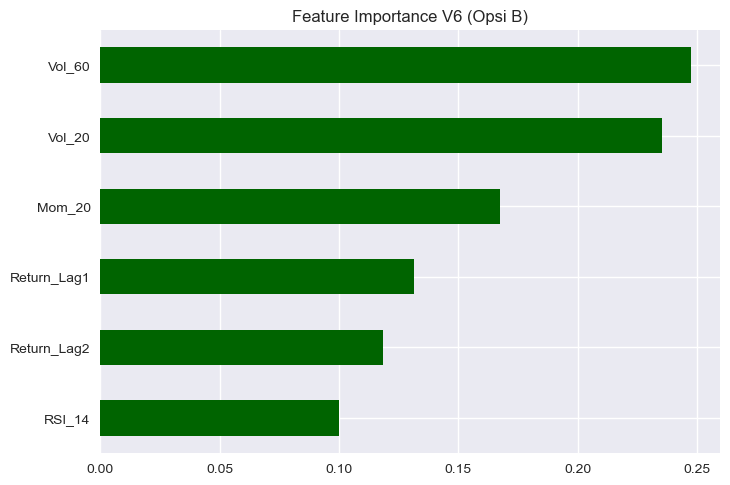

In [5]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values()
importances.plot(kind='barh', color='darkgreen')
plt.title("Feature Importance V6 (Opsi B)")
plt.show()

## 💡 Kesimpulan Eksperimen Opsi B

Dengan menambahkan **RSI** dan **Lagged Returns**, model kini memiliki informasi yang lebih responsif. 
- Jika RSI sangat tinggi, model bisa belajar bahwa tren kenaikan mungkin segera berakhir (Reversal).
- Jika return kemarin positif, model bisa menangkap efek momentum harian.

Jika akurasi testing menunjukkan perbaikan dibanding V2, maka menambahkan 'kedalaman' informasi pada fitur adalah kunci untuk tesis Anda.